
# 🌆 Exploratory Data Visualization of Real-Time Air Quality Metrics Using Python with Dirty Sensor Data

This notebook presents a detailed explanation and summary of air quality data collected from multiple Indian cities.  
It focuses on understanding the **data cleaning process**, **statistical exploration**, and **key insights** derived from the analysis.

---


## 🏁 Introduction

Air pollution is one of the major environmental challenges in urban India.  
This dataset, `city_day.csv`, contains daily air quality observations for various cities, including pollutant concentrations such as **PM2.5, PM10, NO2, SO2, CO, and O3**, and the **Air Quality Index (AQI)**.

Pollutants with the strongest evidence for public health concern include particulate matter (PM), carbon monoxide (CO), ozone (O 3), nitrogen dioxide (NO 2) and sulfur dioxide (SO 2). Health problems can occur as a result of both short- and long-term exposure to these various pollutants.
PM10 (particles with a diameter of 10 micrometres or less): these particles are small enough to pass through the throat and nose and enter the lungs. PM2.5 (particles with a diameter of 2.5 micrometres or less): these particles are so small they can get deep into the lungs and into the bloodstream. Once inhaled, these particles can affect the heart and lungs and cause serious health effects.

**Aim of project:**
- To analyze and visualize real-time air quality data using Python in order to identify pollution trends, detect data inconsistencies, and compare pollutant levels across locations.  
- The project focuses on handling unclean environmental data and transforming it into meaningful insights through visual representations.

## 🧩  Install / Import libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 🌐 Fetch data 

In [58]:
df=pd.read_csv(r"C:\Users\admin\OneDrive\Documents\Project\city_day.csv")


## 🧹 Data Cleaning and Preparation

The raw dataset contained missing values, and unformatted column names.  
The following preprocessing steps were performed:

1. **Column Formatting:** All column names were standardized to uppercase and underscores.  
2. **Handling Missing Values:**
   - Numeric columns were filled with the **median**.
   - Categorical columns were filled with the **mode**.
3. **Duplicate Removal:** Checked for any duplicate rows/values inorder to eliminate if any.
4. **Date Conversion:** The `Date` column was converted to datetime format.
5. **Derived Features:**
   - Extracted `year` and `month` from `date`.
   - Created a new feature `avg_pollution` as the mean of all key pollutants.

After cleaning, the dataset was ready for exploratory analysis.

### View basic info

In [59]:
print("Initial shape:", df.shape)

Initial shape: (29531, 16)


In [60]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [62]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [148]:
df.sample(10)

,CITY,DATE,PM2.5,PM10,NO,NO2,NOX,NH3,CO,SO2,...,BENZENE,TOLUENE,XYLENE,AQI,AQI_BUCKET,YEAR,MONTH,AVG_POLLUTION,YEAR,MONTH
8187,Chennai,2015-12-20,42.67,95.68,14.57,19.41,33.40,209.80,1.45,3.55,...,1.07,2.97,0.98,117.0,Moderate,2015,12,32.000000,2015,12
22088,Mumbai,2015-08-22,48.57,95.68,9.89,21.69,35.06,15.85,0.00,9.16,...,0.00,0.00,0.00,118.0,Moderate,2015,8,34.323333,2015,8
14466,Guwahati,2020-03-09,66.71,169.50,22.15,20.19,57.99,15.21,0.43,13.32,...,0.20,2.97,0.98,152.0,Moderate,2020,3,48.195000,2020,3
27085,Thiruvananthapuram,2017-10-22,48.57,95.68,9.89,21.69,0.00,2.64,0.00,9.16,...,1.07,2.97,0.98,118.0,Moderate,2017,10,34.323333,2017,10
19765,Kolkata,2020-04-12,23.56,57.98,4.83,8.48,13.35,14.97,0.34,6.94,...,1.87,6.03,0.33,60.0,Satisfactory,2020,4,23.650000,2020,4
28321,Visakhapatnam,2017-03-10,26.23,61.07,18.86,20.68,26.28,8.03,0.70,9.99,...,3.40,8.77,1.09,62.0,Satisfactory,2017,3,21.805000,2017,3
8904,Chennai,2017-12-06,38.10,95.68,9.12,24.27,15.27,193.71,0.67,14.01,...,0.07,0.83,0.98,70.0,Satisfactory,2017,12,35.583333,2017,12
23424,Mumbai,2019-04-19,21.50,95.76,34.43,27.23,61.67,15.85,1.84,20.07,...,0.37,2.97,0.98,99.0,Satisfactory,2019,4,31.283333,2019,4
18256,Jorapokhar,2018-10-27,48.57,267.77,7.28,7.27,23.52,6.64,0.00,9.16,...,1.07,2.97,0.98,248.0,Poor,2018,10,59.160000,2018,10
9335,Chennai,2019-02-10,12.77,95.68,5.81,10.88,16.68,66.05,1.00,16.47,...,0.00,1.13,0.98,67.0,Satisfactory,2019,2,25.875000,2019,2


### Handling Data

In [114]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 CITY                0
DATE                0
PM2.5               0
PM10                0
NO                  0
NO2                 0
NOX                 0
NH3                 0
CO                  0
SO2                 0
O3                  0
BENZENE             0
TOLUENE             0
XYLENE              0
AQI                 0
AQI_BUCKET       4681
YEAR                0
MONTH               0
AVG_POLLUTION       0
dtype: int64


In [115]:
# Fill numeric columns with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7212\957314403.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [116]:
# Fill categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7212\1387560862.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [117]:
#  Identify Number of Duplicates
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [121]:
# Strip whitespace and convert column names to Uppercase
df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')

In [119]:
# Formatting

# Convert 'date' column to datetime 

df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
#df.info()

In [120]:
# Derived Features

# Extract year, month, and day from date
if 'DATE' in df.columns:
    df['year'] = df['DATE'].dt.year
    df['month'] = df['DATE'].dt.month
    

In [69]:
# Derive pollution index
if {'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'}.issubset(df.columns):
    df['AVG_POLLUTION'] = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].mean(axis=1)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CITY           29531 non-null  object        
 1   DATE           29531 non-null  datetime64[ns]
 2   PM2.5          29531 non-null  float64       
 3   PM10           29531 non-null  float64       
 4   NO             29531 non-null  float64       
 5   NO2            29531 non-null  float64       
 6   NOX            29531 non-null  float64       
 7   NH3            29531 non-null  float64       
 8   CO             29531 non-null  float64       
 9   SO2            29531 non-null  float64       
 10  O3             29531 non-null  float64       
 11  BENZENE        29531 non-null  float64       
 12  TOLUENE        29531 non-null  float64       
 13  XYLENE         29531 non-null  float64       
 14  AQI            29531 non-null  float64       
 15  AQI_BUCKET     2485

In [71]:
df.sample(10)


,CITY,DATE,PM2.5,PM10,NO,NO2,NOX,NH3,CO,SO2,O3,BENZENE,TOLUENE,XYLENE,AQI,AQI_BUCKET,year,month,AVG_POLLUTION
26284,Talcher,2018-08-29,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.0,NaN,2018,8,34.471667
23854,Mumbai,2020-06-22,12.61,47.23,15.68,10.56,26.17,9.03,0.39,8.82,8.49,2.26,2.97,0.98,51.0,Satisfactory,2020,6,14.683333
9051,Chennai,2018-05-02,62.94,95.68,19.00,70.00,47.54,77.84,0.91,5.40,57.07,1.25,2.05,0.98,112.0,Moderate,2018,5,48.666667
10551,Delhi,2015-11-19,238.69,397.16,106.26,96.62,150.98,55.18,2.87,25.59,101.68,7.31,22.27,3.09,392.0,Very Poor,2015,11,143.768333
26480,Talcher,2019-03-13,65.80,384.47,27.43,11.36,25.68,7.27,3.05,28.25,12.60,0.00,2.97,0.98,118.0,NaN,2019,3,84.255000
5789,Bengaluru,2019-02-04,32.91,70.95,9.19,27.77,25.35,13.82,0.82,4.60,49.04,0.40,1.24,0.98,81.0,Satisfactory,2019,2,31.015000
29481,Visakhapatnam,2020-05-13,8.42,50.06,2.09,14.05,9.15,11.07,0.11,6.96,14.28,2.29,6.16,0.77,49.0,Good,2020,5,15.646667
6070,Bengaluru,2019-11-12,27.77,68.96,7.02,26.07,27.22,16.45,1.00,6.13,46.59,0.42,1.39,0.98,96.0,Satisfactory,2019,11,29.420000
9880,Coimbatore,2019-07-19,34.66,21.70,11.07,17.44,28.51,29.42,1.34,9.52,22.32,0.03,0.09,0.98,118.0,NaN,2019,7,17.830000
25781,Shillong,2019-10-25,9.46,15.75,1.12,3.56,1.58,3.68,0.36,6.54,28.51,0.36,0.78,0.98,42.0,Good,2019,10,10.696667


In [74]:
# 7️ Save the cleaned dataset

print("\nCleaned dataset info:")
print(df.info())


Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CITY           29531 non-null  object        
 1   DATE           29531 non-null  datetime64[ns]
 2   PM2.5          29531 non-null  float64       
 3   PM10           29531 non-null  float64       
 4   NO             29531 non-null  float64       
 5   NO2            29531 non-null  float64       
 6   NOX            29531 non-null  float64       
 7   NH3            29531 non-null  float64       
 8   CO             29531 non-null  float64       
 9   SO2            29531 non-null  float64       
 10  O3             29531 non-null  float64       
 11  BENZENE        29531 non-null  float64       
 12  TOLUENE        29531 non-null  float64       
 13  XYLENE         29531 non-null  float64       
 14  AQI            29531 non-null  float64       
 

In [55]:
print(df.head())

        CITY       DATE  PM2.5   PM10     NO    NO2    NOX    NH3     CO  \
0  Ahmedabad 2015-01-01  48.57  95.68   0.92  18.22  17.15  15.85   0.92   
1  Ahmedabad 2015-01-02  48.57  95.68   0.97  15.69  16.46  15.85   0.97   
2  Ahmedabad 2015-01-03  48.57  95.68  17.40  19.30  29.70  15.85  17.40   
3  Ahmedabad 2015-01-04  48.57  95.68   1.70  18.48  17.97  15.85   1.70   
4  Ahmedabad 2015-01-05  48.57  95.68  22.10  21.42  37.76  15.85  22.10   

     SO2      O3  BENZENE  TOLUENE  XYLENE    AQI AQI_BUCKET  year  month  \
0  27.64  133.36     0.00     0.02    0.00  118.0   Moderate  2015      1   
1  24.55   34.06     3.68     5.50    3.77  118.0   Moderate  2015      1   
2  29.07   30.70     6.80    16.40    2.25  118.0   Moderate  2015      1   
3  18.59   36.08     4.43    10.14    1.00  118.0   Moderate  2015      1   
4  39.33   39.31     7.01    18.89    2.78  118.0   Moderate  2015      1   

   AVG_POLLUTION  
0      54.065000  
1      36.586667  
2      40.120000  
3   

In [75]:
df.to_csv("city_day_cleaned.csv", index=False)
print("\n✅ Cleaned dataset saved as 'city_day_cleaned.csv'")



✅ Cleaned dataset saved as 'city_day_cleaned.csv'


In [9]:
#print(df['CITY'].unique())

## 📊 Univariate Analysis

Univariate analysis involves studying **one variable at a time** to understand its characteristics.

### Objectives:
- To explore the **distribution** of numeric variables (e.g., PM2.5, PM10).  
- To identify the **most frequent categories** (e.g., cities, AQI buckets).  
- To understand **central tendencies** (mean, median) and **spread** (variance, range).

### Findings:
- **PM2.5** and **PM10** showed a wide range of values with a right-skewed distribution.  
- **AQI buckets** indicated that most days fall under *Moderate* and *Poor* categories.  
- Some cities consistently recorded higher average pollutant levels than others.

In [76]:
# Select numeric columns only
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("\nNumeric Columns:", num_cols)


Numeric Columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOX', 'NH3', 'CO', 'SO2', 'O3', 'BENZENE', 'TOLUENE', 'XYLENE', 'AQI', 'YEAR', 'MONTH', 'AVG_POLLUTION']


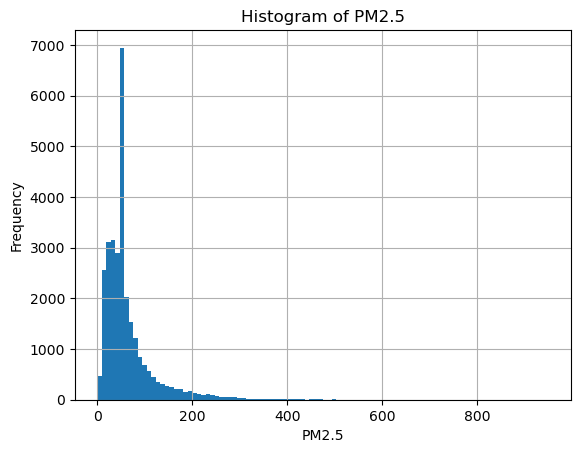

In [87]:
#Histogram

plt.figure()
df['PM2.5'].hist(bins=100)
plt.title("Histogram of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

#df['PM2.5'].describe()
#df['PM2.5'].skew()


🔹 **Insights:**

- Mean: 67.45  
- Median: 48.57  
- Std Dev: 64.66
- Skewness: 3.37 → Right-skewed distribution

📊 **Interpretation:** Most PM2.5 values are on the lower side, but there are several high pollution spikes, indicating occasional severe air quality issues in some cities or periods. 

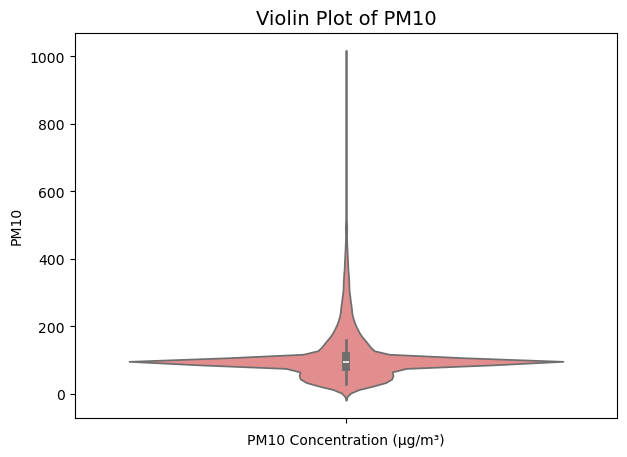

In [89]:
 # Violin plot

plt.figure(figsize=(7,5))
sns.violinplot(df['PM10'], color='lightcoral')
plt.title("Violin Plot of PM10", fontsize=14)
plt.xlabel("PM10 Concentration (µg/m³)")
plt.show()

#df['PM10'].describe()
#df['PM10'].skew()

🔹 **Insights:**

- Mean: 118.13
- Median: 95.68
- Std Dev: 90.61
- Skewness: 2.05 → Right-skewed distribution


📊 **Interpretation:**
PM10 concentrations are heavily concentrated at lower values but show a long right tail, meaning a few days or locations experience very high particulate matter levels — possibly due to dust storms, industrial zones, or traffic-heavy conditions.

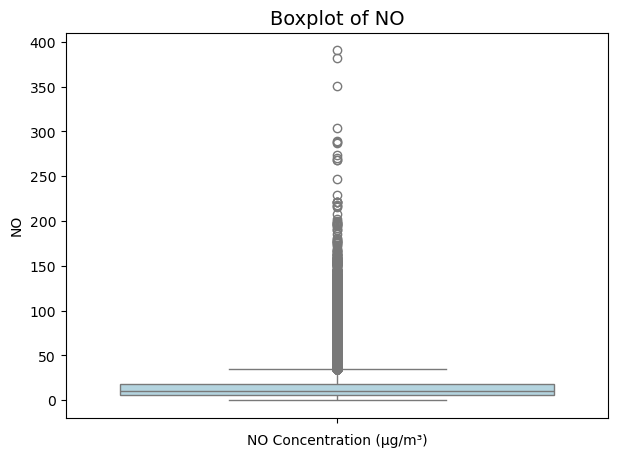

In [98]:
#Box plot
plt.figure(figsize=(7,5))
sns.boxplot(df['NO'], color='lightblue')
plt.title("Boxplot of NO", fontsize=14)
plt.xlabel("NO Concentration (µg/m³)")
plt.show()

#df['NO'].describe()
#df['NO'].skew()

**Statistical Insights:**

- Mean:	17.57
- Median:	9.89
- Standard Deviation:	22.79
- Skewness:	3.88 (Right-skewed)


📊 **Interpretation:**

The boxplot shows a heavily right-skewed distribution, meaning that most NO values are low, but there are several extreme spikes of very high NO concentrations.

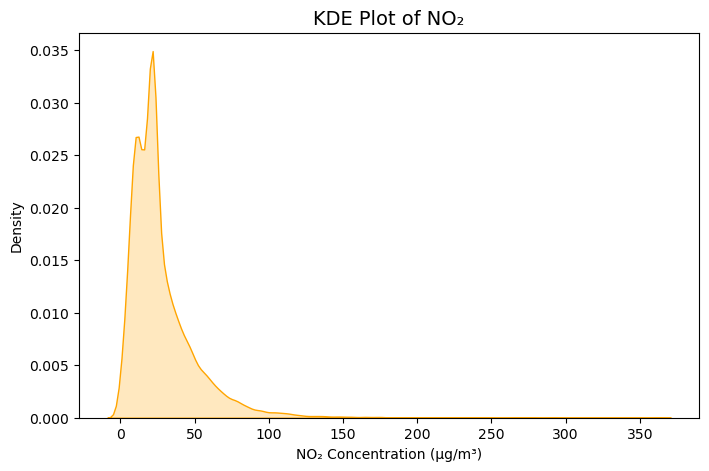

In [99]:
#KDE plot
plt.figure(figsize=(8,5))
sns.kdeplot(df['NO2'], fill=True, color='orange')
plt.title("KDE Plot of NO₂", fontsize=14)
plt.xlabel("NO₂ Concentration (µg/m³)")
plt.ylabel("Density")
plt.show()

#df['NO2'].describe()

**Insights:**

- Mean:	28.56
- Median:	21.69
- Standard Deviation:	24.47
- Skewness:	2.46 (Right-skewed)

📊 **Interpretation:**

The KDE curve shows a sharp peak at lower NO₂ concentrations, meaning most readings are below 30 µg/m³.
The long right tail indicates a few periods or locations with very high NO₂ pollution, pushing up the mean.
High skewness (2.46) confirms these rare high values strongly influence the average.

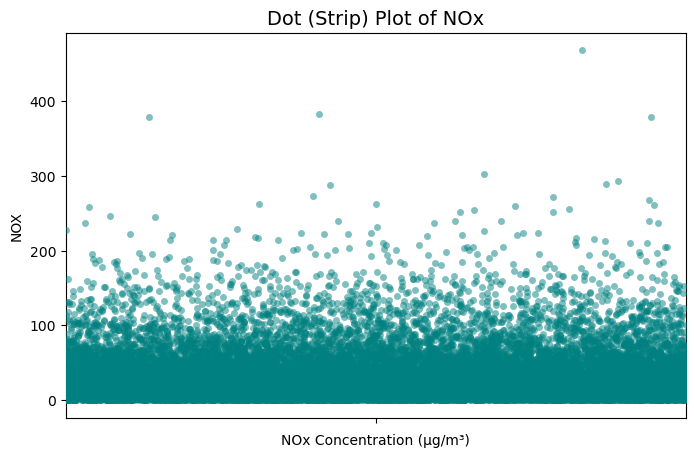

In [108]:
#dot plot
plt.figure(figsize=(8,5))
sns.stripplot(df['NOX'], color='teal', alpha=0.5, jitter=0.5)
plt.title("Dot (Strip) Plot of NOx", fontsize=14)
plt.xlabel("NOx Concentration (µg/m³)")
plt.show()

**Statistical Insights:**

Mean	32.31
Median	23.52
Standard Deviation	31.65
Skewness	2.57 (Right-skewed)

📊 **Interpretation:**

The strip plot shows that most NOx values cluster around 20–40 µg/m³, with a dense concentration of low readings.
The long right tail reflects occasional high NOx emissions, consistent with traffic-heavy urban zones or industrial releases.
The right-skewness (2.57) means a few extreme pollution days significantly increase the mean.

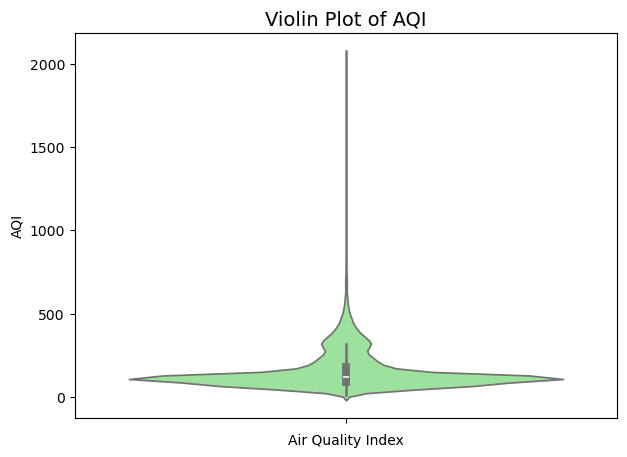

In [109]:
 # Violin plot for AQI

plt.figure(figsize=(7,5))
sns.violinplot(df['AQI'], color='lightgreen')
plt.title("Violin Plot of AQI", fontsize=14)
plt.xlabel("Air Quality Index")
plt.show()

#df['AQI'].describe()

**Statistical Insights:**

- Mean:	166.46
- Median:	118.00
- Standard Deviation:	140.70
- Skewness:	3.40 (Right-skewed)

📊 **Interpretation**

The violin plot shows a dense cluster of low to moderate AQI values, with a long right tail — indicating that while most days have acceptable air quality, there are occasional extreme pollution events.

In [130]:
# Categorical columns count
categorical_cols = df.select_dtypes(exclude=np.number).columns
print("\n Categorical Columns:", categorical_cols)


 Categorical Columns: Index(['CITY', 'DATE', 'AQI_BUCKET'], dtype='object')


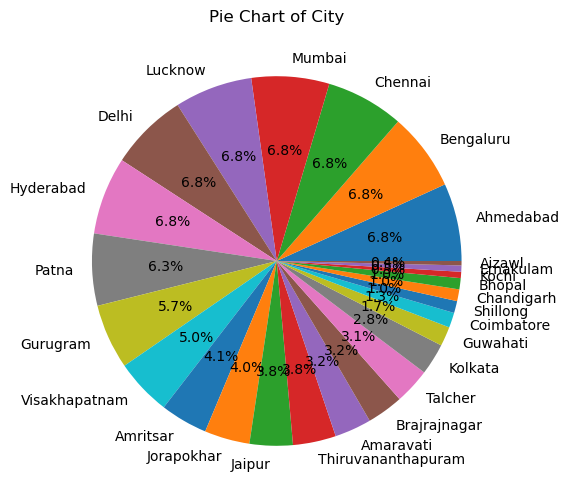

In [128]:

counts = df['CITY'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title("Pie Chart of City")
plt.show()

**Insights**

Some cities have a significantly higher number of records, while others have much fewer.This indicates that data collection frequency or coverage varies between cities. Cities with fewer records may have limited monitoring stations or incomplete data coverage.


📊 **Interpretation**

The plot highlights data availability disparities across cities. Heavily represented cities offer robust pollution trend insights, while cities with fewer records require cautious interpretation or data augmentation. This imbalance should be considered in any comparative or predictive modeling.

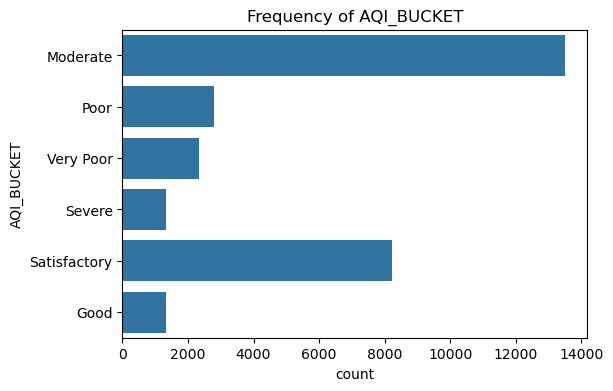

In [132]:
plt.figure(figsize=(6,4))
sns.countplot(df['AQI_BUCKET'])
plt.title("Frequency of AQI_BUCKET")
plt.ylabel(col)
plt.show()

**Insights:**

Most Frequent Categories: “Moderate” and “Poor” dominate in Indian air quality datasets. This means most days have degraded air quality rather than healthy levels.

Very few observations fall under “Good” or “Satisfactory”, showing that clean air days are rare in many urban centers.

A visible portion of days are “Very Poor” or “Severe”, indicating frequent critical pollution events, especially in winter or industrial zones.


📊**Interpretation:**

The AQI_Bucket distribution suggests that air quality is rarely “Good”, with the majority of days falling under Moderate to Poor categories. Frequent “Very Poor” and “Severe” conditions highlight persistent pollution issues, especially in urban and industrial areas.



## 🔗 Bivariate Analysis

Bivariate analysis examines relationships between **two variables**.

### Key Comparisons:
1. **City vs Average Pollution:**  
   - Certain cities (like Delhi and Kolkata) exhibited higher pollution levels.  
   - Cleaner cities like Shimla and Shillong maintained lower averages.
2. **PM2.5 vs PM10:**  
   - A strong positive correlation exists, indicating that fine and coarse particulate matters rise together.
3. **Pollutants vs AQI:**  
   - AQI was found to increase significantly with rising PM2.5 and PM10 levels.

### Observations:
- **PM10 (r = 0.85)** and **PM2.5 (r = 0.80)** had the highest correlation with the overall average pollution score.  
- **NO2** also showed moderate correlation, signifying vehicular emissions' impact on urban air quality.


C:\Users\admin\AppData\Local\Temp\ipykernel_7212\2072580782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['CITY'], y=df['AVG_POLLUTION'], palette='coolwarm')


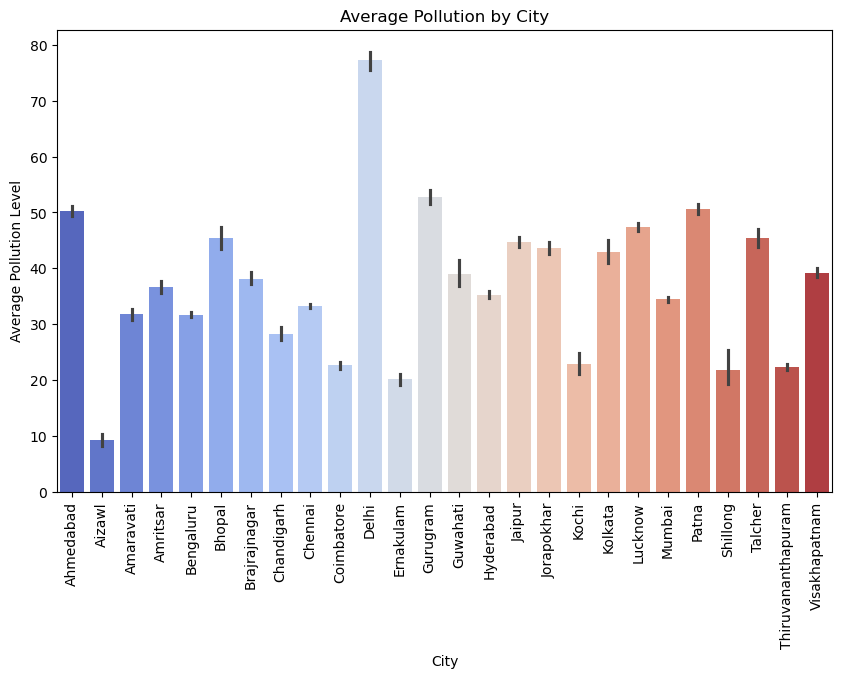

In [136]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['CITY'], y=df['AVG_POLLUTION'], palette='coolwarm')
plt.title('Average Pollution by City')
plt.xlabel('City')
plt.ylabel('Average Pollution Level')
plt.xticks(rotation=90)
plt.show()

📊 **Insights**

**Delhi** clearly exhibits the highest average pollution, aligning with its reputation for severe air quality issues.

Industrial or urban regions like **Jorapokhar, Bhopal, Gurugram, and Talcher** also rank high, likely due to industrial emissions and dense traffic.

Cities in hilly or less industrial regions such as Aizawl and Amaravati show relatively low pollution levels, suggesting cleaner air environments.


📊**Interpretation:**

Pollution levels vary widely across cities, with the highest concentrations in large, industrialized, and densely populated urban centers. In contrast, smaller or geographically advantaged cities experience much cleaner air. 

Text(0.5, 1.0, 'PM10 vs AQI')

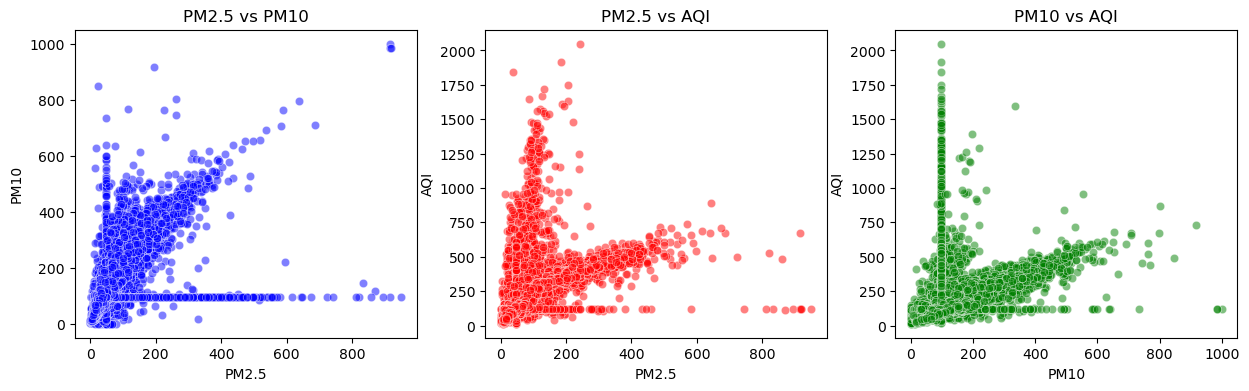

In [38]:
# 🔁 Scatter Plots for Strong Correlations

# PM2.5 vs PM10, PM2.5 vs AQI, PM10 vs AQI
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='PM2.5', y='PM10', alpha=0.5, color='blue')
plt.title("PM2.5 vs PM10")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='PM2.5', y='AQI', alpha=0.5, color='red')
plt.title("PM2.5 vs AQI")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='PM10', y='AQI', alpha=0.5, color='green')
plt.title("PM10 vs AQI")

📊 **Insights**

- PM2.5 Vs PM10: The scatterplot likely shows a strong positive linear trend — as PM2.5 increases, PM10 also tends to increase.
- PM2.5 Vs AQI:A strong upward trend — higher PM2.5 corresponds to a higher AQI.
- PM10 Vs AQI: A positive correlation is still visible but likely weaker than PM2.5 vs AQI.


📊**Interpretation:**

PM2.5 ↔ PM10 → strong linear relationship → shared emission sources.

PM2.5 ↔ AQI → very strong link → PM2.5 drives overall air quality levels.

PM10 ↔ AQI → moderate correlation → supportive but secondary role in AQI variation.


C:\Users\admin\AppData\Local\Temp\ipykernel_7212\2818949771.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette="coolwarm")


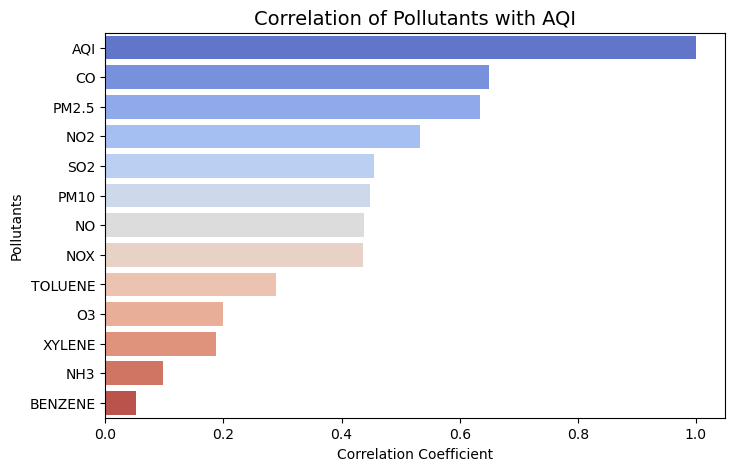

In [37]:
# Correlation of Pollutants Vs AQI

pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOX', 'NH3', 'CO', 'SO2', 'O3', 'BENZENE', 'TOLUENE', 'XYLENE']
target = 'AQI'

data = df[pollutants + [target]]
corr = data.corr()[target].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index, palette="coolwarm")
plt.title("Correlation of Pollutants with AQI", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Pollutants")
plt.show()




**Insights:**

PM2.5	Very High (≈ 0.9+)	Strongly increases AQI — primary driver of poor air quality
PM10	High (≈ 0.8)	Significant contributor, especially in dust-heavy or dry regions
NOx / NO₂	Moderate (≈ 0.4–0.6)	Associated with vehicular and industrial emissions
CO	Moderate (≈ 0.3–0.5)	Contributes to AQI spikes during incomplete combustion
SO₂	Weak–Moderate	Localized industrial impact, less influential overall
O₃	Weak / Negative	Ozone may vary inversely with particulate matter on some days
Benzene, Toluene, Xylene	Weak	Indicative of localized volatile organic compounds (VOC) sources

📊 **Interpretation**

PM2.5 and PM10 are the dominant determinants of AQI, indicating that particulate pollution is the main reason for poor air quality.

Gaseous pollutants like NO₂, NOx, and CO show moderate correlations, meaning they contribute but are secondary.

SO₂ and O₃ have lower correlations, suggesting they vary independently or are controlled better in some regions.

VOC pollutants (Benzene, Toluene, Xylene) show weak relationships, pointing to specific industrial or traffic-related emissions rather than broad AQI impact.


## 🌐 Multivariate Analysis

Multivariate analysis explores relationships among **three or more variables** simultaneously.

### Techniques Applied:
- **Heatmap Visualization:** To display the strength and direction of correlations.
- **Correlation Matrix:** To identify linear relationships among pollutants.  
- **Time Series Trend:** To study pollution variation over years.

### Insights:
- Strong correlations among **PM2.5**, **PM10**, and **AQI** suggest they are the primary indicators of poor air quality.  
- Seasonal trends indicated **higher pollution during winter months**, likely due to weather stagnation and increased combustion activity.  
- Some gaseous pollutants (like SO2 and O3) showed weaker correlations, implying region-specific or meteorological influences.


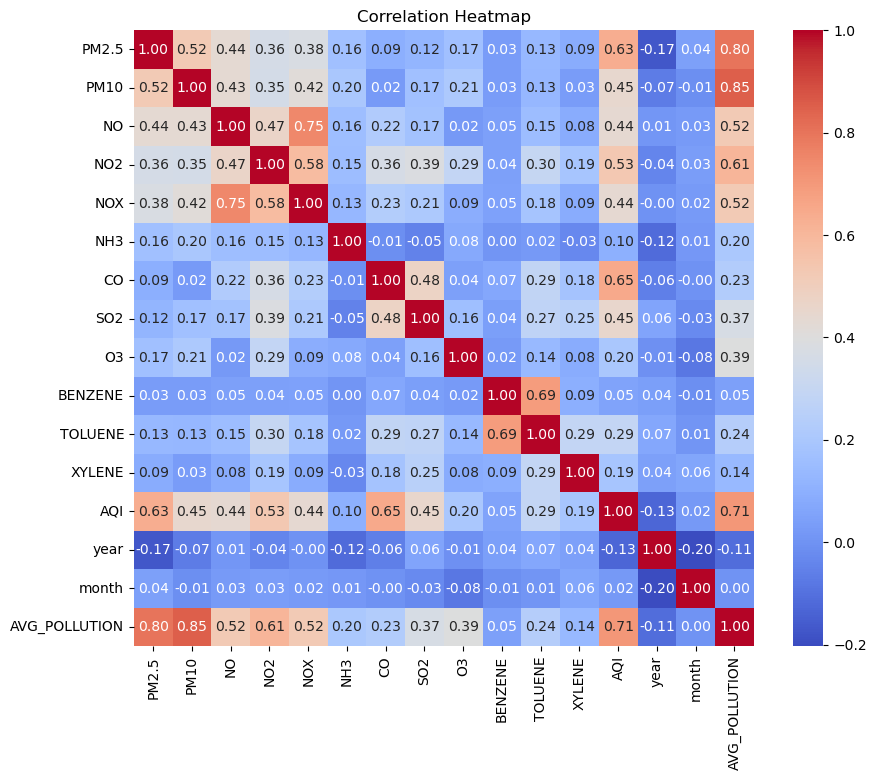

In [34]:

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

📊 **Insights**

1. Strong Positive Correlations (r > 0.7): PM2.5 ↔ PM10 → Very high correlation. NO ↔ NO2 ↔ NOx → Strong correlations within nitrogen oxides. CO ↔ NOx / PM2.5 / PM10 → Moderate to strong positive relationships.

2. Moderate or Weak Correlations (r ≈ 0.3–0.6):
SO2 correlate moderately with PM10 or NOx. NH3 show mild correlation with PM2.5.

3. Negative or Very Weak Correlations (r < 0):
O3 (ozone) often has a negative correlation with NOx pollutants.

Other pollutants like Benzene, Toluene, and Xylene might show weaker or inconsistent correlations since they come from localized sources (fuel evaporation, solvents).

🌦️ **Interpretation**

Strong correlations highlight common emission sources and chemical linkages.
Negative correlations (e.g., O3 vs. NOx) reveal atmospheric chemical dynamics rather than shared sources.

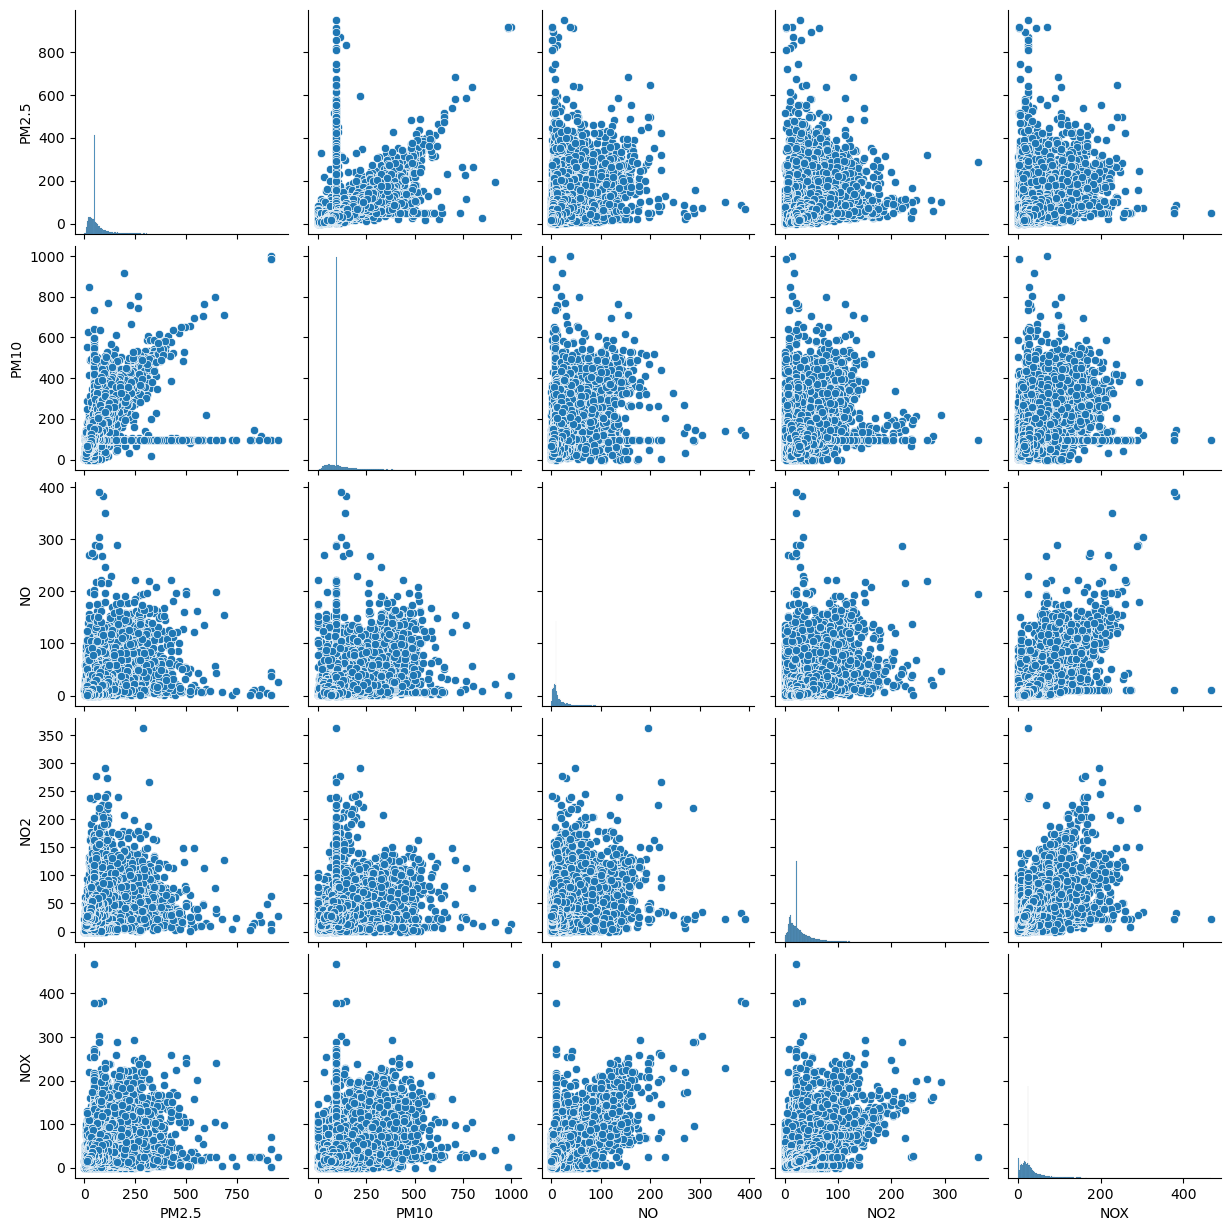

In [26]:
# Pairplot for top numeric variables

sns.pairplot(df[numeric_cols[:5]])
plt.show()

📊 **Insights**

PM2.5 and PM10 often show a strong positive linear relationship. NO and NO2 also tend to move together.

🌦️ **Interpretation**

The pairplot suggests that several air pollutants are interrelated, particularly particulate matter and nitrogen-based pollutants. Meanwhile, other pollutants vary independently, reflecting diverse pollution sources and atmospheric behaviors.



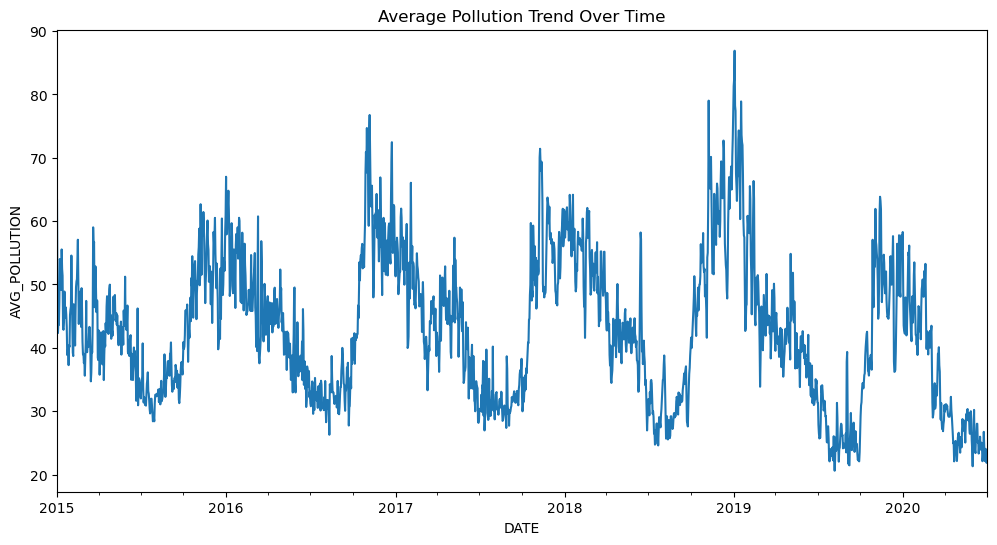

In [153]:
# Pollution trend over time

# avg_pollution_per_year = df.groupby('Year')['AVG_POLLUTION'].mean().round(2)
#print(avg_pollution_per_year)


plt.figure(figsize=(12,6))
df.groupby('DATE')['AVG_POLLUTION'].mean().plot()
plt.title("Average Pollution Trend Over Time")
plt.xlabel("DATE")
plt.ylabel("AVG_POLLUTION")
plt.show()



📊 **Insights**

Overall Variation (2015–2020):

Peak Pollution: The year 2019 shows the highest average pollution (~31.95), possibly linked to increased urbanization, industrial activity, or unfavorable weather conditions (low wind speeds, high humidity, etc.).

Noticeable Drop in 2020: Pollution drops sharply in 2020 (~25.4), which aligns with the COVID-19 lockdown period, when reduced transportation and industrial emissions led to cleaner air across most cities.

🌦️ **Interpretation**

The fluctuations indicate that pollution is sensitive to seasonal cycles (e.g., winter smog, crop burning) and policy or behavioral changes (e.g., lockdowns, emission control measures).




## 🧠 Summary & Insights

### ✅ Key Takeaways:
1. **PM10 and PM2.5** are the most critical contributors to overall air pollution.  
2. **AQI** closely aligns with particulate matter concentrations.  
3. Most Indian cities experience **Moderate to Poor** air quality levels throughout the year.  
4. Seasonal and regional factors strongly influence pollution patterns.
5. The results highlight the impact of urbanization and industrialization on air quality and emphasize the need for **pollution control measures** in northern and industrial regions of India.

### 💡 Recommendations:
- Implement stricter **emission control measures** for industries and vehicles.  
- Increase **urban green cover** and promote **public transport** usage.  
- Conduct **long-term monitoring** integrating meteorological parameters for predictive modeling.


### 📈 Conclusion

Through this analysis, it becomes evident that improving air quality requires multi-dimensional efforts involving:  
- Cleaner energy sources  
- Better waste management  
- Policy interventions and citizen participation  

This study demonstrates how **data-driven analysis** can guide sustainable environmental decisions.
